In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')

In [2]:
from hedging import PriceSimulator, GreeksEngine, delta_hedge_pnl, var_cvar

## Delta Hedging Simulation 

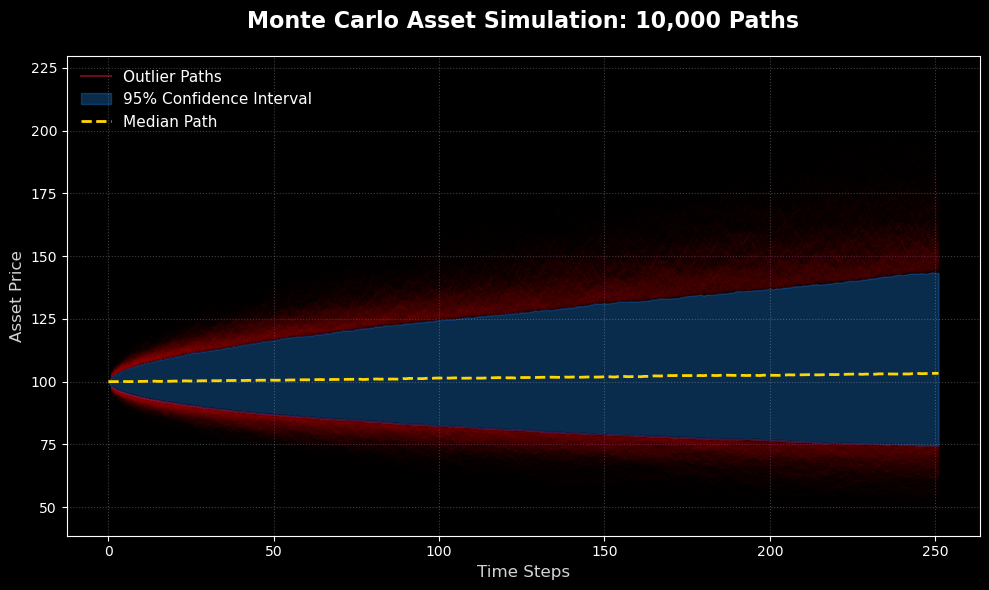

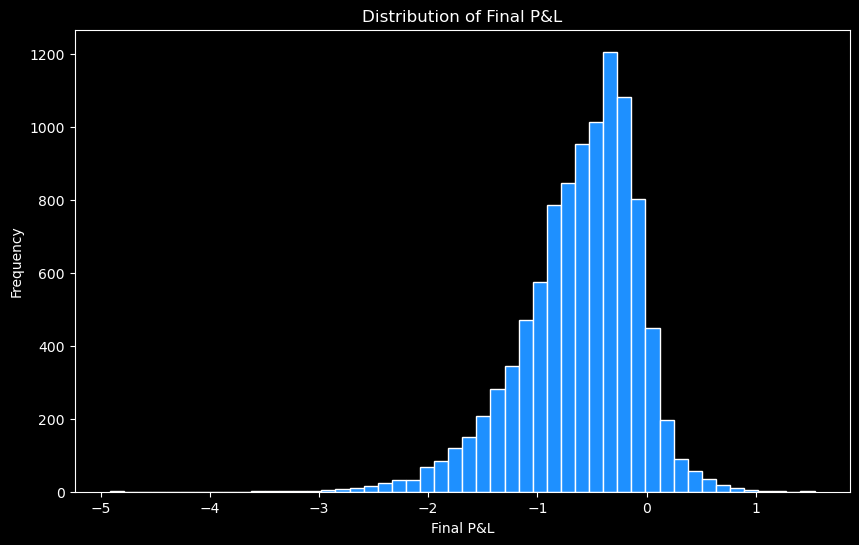

In [3]:
T = 1
sigma = 0.2
n = 252
m = 10_000
K = 110
r = 0.03
fee_rate = 0.001

sim = PriceSimulator(100, 0.05, 0.2, T, n, m, "GBM") # mu is the real-world drift (P measure), not the risk-free rate (Q measure)
paths = sim.simulate()

greek = GreeksEngine("Call", K, r)
premium = greek.price(100, sigma, T, 0)

t = np.linspace(0, T, n)
all_deltas = greek.compute_all_deltas(paths, sigma, T, t)
final_PnL = delta_hedge_pnl(paths, all_deltas, premium, r, T, t, fee_rate, K)
VaR_95, CVaR_95 = var_cvar(final_PnL, 0.95)
adjusted_premium = premium + CVaR_95

median_path = np.median(paths, axis=0)
upper_95 = np.percentile(paths, 95, axis=0)
lower_5 = np.percentile(paths, 5, axis=0)
time_steps = np.arange(paths.shape[1])

outside_mask = (paths > upper_95) | (paths < lower_5)
outlier_rows = np.any(outside_mask, axis=1)
outlier_paths = np.where(outside_mask, paths, np.nan)[outlier_rows]

# Plotting paths
plt.figure(figsize=(10, 6))
plt.plot([], [], color='crimson', alpha=0.5, label='Outlier Paths')
plt.plot(outlier_paths.T, color='crimson', alpha=0.01)
plt.fill_between(time_steps, lower_5, upper_95, color='dodgerblue', alpha=0.3, label="95% Confidence Interval")

plt.plot(time_steps, median_path, color="gold", linewidth=2, label="Median Path", linestyle="--")

plt.title(f"Monte Carlo Asset Simulation: {m:,} Paths", fontsize=16, fontweight='bold', pad=20, color='white')

plt.xlabel("Time Steps", fontsize=12, color="lightgray")
plt.ylabel("Asset Price", fontsize=12, color="lightgray")

plt.grid(True, linestyle=":", alpha=0.3, color="lightgray" )
plt.legend(loc="upper left", frameon=False, fontsize=11)
plt.tight_layout()

plt.show()

plt.figure(figsize=(10, 6))
plt.hist(final_PnL, color="dodgerblue", bins=50, edgecolor="white")
plt.xlabel("Final P&L")
plt.ylabel("Frequency")
plt.title("Distribution of Final P&L")
plt.show()

In [4]:
print("-" * 40)
print(f"final P&L mean: {final_PnL.mean()}")
print(f"final P&L SD: {final_PnL.std()}")
print(f"VaR 95%: {VaR_95}\nCVaR 95% = {CVaR_95}")
print(f"BS premium: {premium:.4f}\nCVaR-adjusted premium: {adjusted_premium:.4f}")
print("-" * 40)

----------------------------------------
final P&L mean: -0.6126799073517827
final P&L SD: 0.5370157112132831
VaR 95%: 1.604567208492443
CVaR 95% = 1.9823966711916114
BS premium: 5.2934
CVaR-adjusted premium: 7.2758
----------------------------------------


### Rebalancing Frequency Analysis

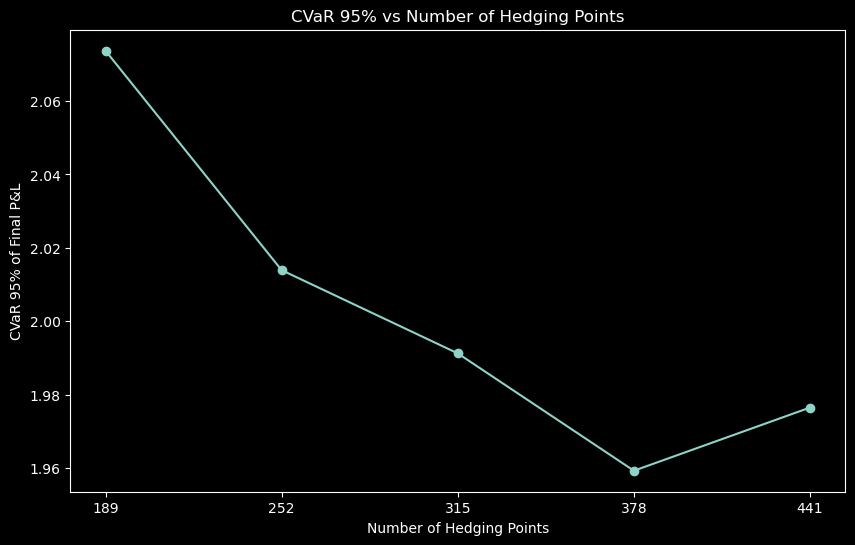

In [5]:
T = 1
sigma = 0.2
m = 10_000
K = 110
r = 0.03
fee_rate = 0.001

n_items = [189, 252, 315, 378, 441]
CVaR_95_list = []

for n in n_items:
    sim = PriceSimulator(100, 0.05, 0.2, T, n, 10_000, "GBM")
    paths = sim.simulate()

    greek = GreeksEngine("Call", K, r)
    premium = greek.price(100, sigma, T, 0)

    t = np.linspace(0, T, n)
    all_deltas = greek.compute_all_deltas(paths, sigma, T, t)
    final_PnL = delta_hedge_pnl(paths, all_deltas, premium, r, T, t, fee_rate, K)
    VaR_95, CVaR_95 = var_cvar(final_PnL, 0.95)
    CVaR_95_list.append(CVaR_95)

plt.figure(figsize=(10, 6))
plt.plot(range(len(n_items)), CVaR_95_list, marker='o')
plt.xticks(range(len(n_items)), n_items)
plt.xlabel("Number of Hedging Points")
plt.ylabel("CVaR 95% of Final P&L")
plt.title("CVaR 95% vs Number of Hedging Points")
plt.show()

## Gamma Hedging Simulation

Note: Gamma hedging adds a second option (K=120) to offset the gamma exposure of the primary option (K=110).
The hedge ratio h = Γ₁/Γ₂ is applied conditionally — only when gamma_1 exceeds the 95th percentile threshold and h ≤ 1 (hedge option has at least as much gamma as the primary).

**Limitations:**
- The 95th percentile gamma threshold is computed from the full gamma_1 matrix (look-ahead) — in a real system it would be rolling or pre-specified  
- This simulation is a closed loop under GBM — not a measure of real-world performance
- Under GBM, gamma hedging shows minimal improvement over delta hedging — real value emerges with jumps and vol clustering (e.g. real BTC data)        
- Transaction costs and liquidity of the hedge option are not realistically modeled

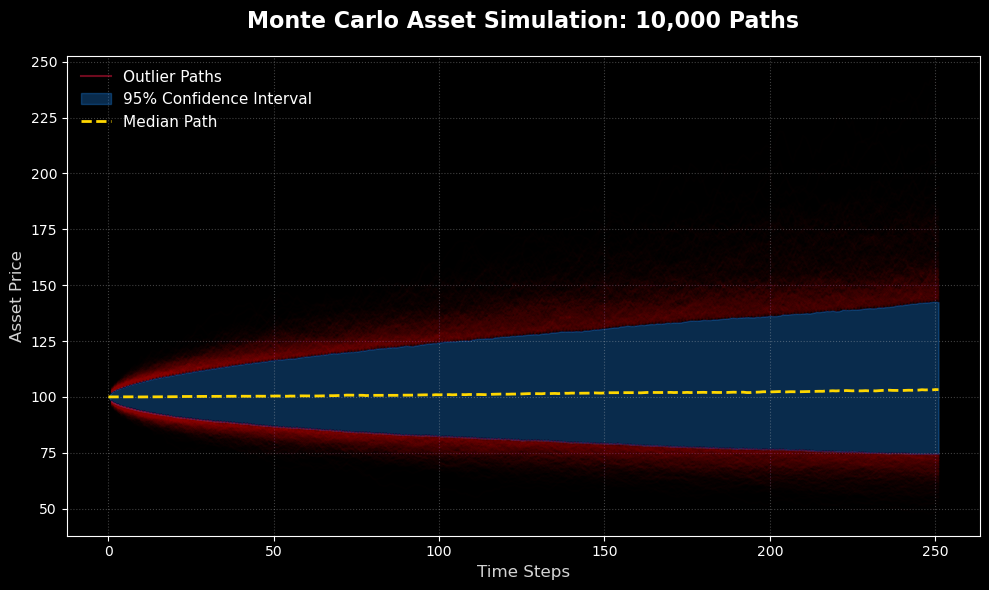

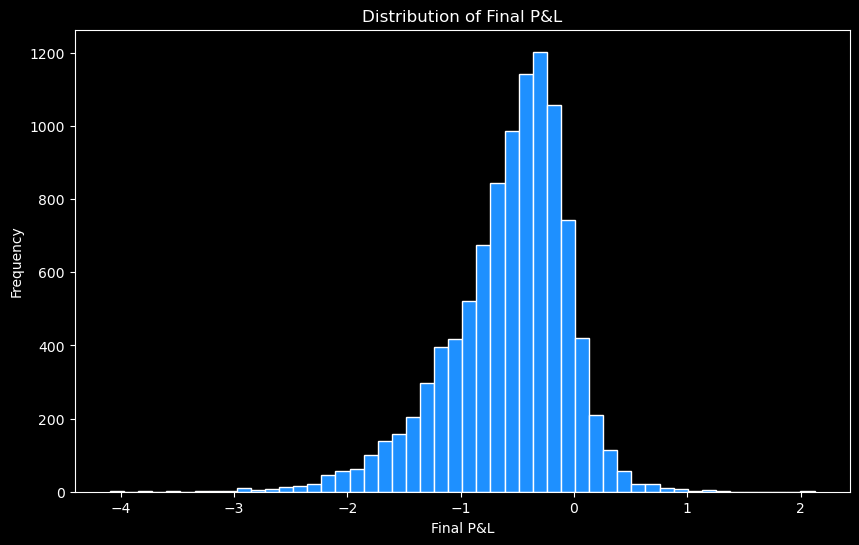

In [ ]:
T = 1
sigma = 0.2
n = 252
m = 10_000
r = 0.03
fee_rate = 0.001
option_fee_rate = 0.001

sim = PriceSimulator(100, 0.05, 0.2, T, n, m, "GBM") # mu is the real-world drift (P measure), not the risk-free rate (Q measure)
paths = sim.simulate()

greek_1 = GreeksEngine("Call", 110, r)
greek_2 = GreeksEngine("Call", 120, r)

premium_1 = greek_1.price(100, sigma, T, 0)

t = np.linspace(0, T, n)
all_deltas_1 = greek_1.compute_all_deltas(paths, sigma, T, t)
all_deltas_2 = greek_2.compute_all_deltas(paths, sigma, T, t)

all_gammas_1 = greek_1.compute_all_gammas(paths, sigma, T, t)
all_gammas_2 = greek_2.compute_all_gammas(paths, sigma, T, t)

gamma1_threshold = np.percentile(all_gammas_1, 95)
active_hedge = all_gammas_1 > gamma1_threshold

h = np.where(active_hedge, all_gammas_1 / np.maximum(all_gammas_2, 1e-6), 0)
h = np.where(np.isfinite(h), h, 0)
h = np.where(h <= 1, h, 0)

h_diff = h[:, 1:] - h[:, :-1]
initial_h_diff = h[:, 0:1]
h_diff = np.hstack([initial_h_diff, h_diff])

# short option1, long h*option2 — hold net_deltas shares to delta-hedge the combined position
net_deltas = all_deltas_1 - h * all_deltas_2
net_deltas_diff = net_deltas[:, 1:] - net_deltas[:, :-1]
initial_net_deltas_diff = net_deltas[:, 0:1]
net_deltas_diff = np.hstack([initial_net_deltas_diff, net_deltas_diff])

option2_prices = greek_2.compute_all_prices(paths, sigma, T, t)

cash_changes = -h_diff * option2_prices - net_deltas_diff * paths
cost = fee_rate * np.abs(net_deltas_diff) * paths + option_fee_rate * np.abs(h_diff) * option2_prices
cash_changes -= cost

time_remaining = T - t
total_cash = premium_1 * np.exp(r * T) + (cash_changes * np.exp(r * time_remaining)).sum(axis=1)
payoff = np.maximum(paths[:, -1] - greek_1.K, 0)
fee_last = fee_rate * np.abs(net_deltas[:, -1]) * paths[:, -1] + option_fee_rate * np.abs(h[:, -1]) * option2_prices[:, -1]
final_PnL = total_cash + net_deltas[:, -1] * paths[:, -1] + h[:, -1] * option2_prices[:, -1] - fee_last - payoff

VaR_95, CVaR_95 = var_cvar(final_PnL, 0.95)
adjusted_premium = premium_1 + CVaR_95

median_path = np.median(paths, axis=0)
upper_95 = np.percentile(paths, 95, axis=0)
lower_5 = np.percentile(paths, 5, axis=0)
time_steps = np.arange(paths.shape[1])

outside_mask = (paths > upper_95) | (paths < lower_5)
outlier_rows = np.any(outside_mask, axis=1)
outlier_paths = np.where(outside_mask, paths, np.nan)[outlier_rows]

# Plotting paths
plt.figure(figsize=(10, 6))
plt.plot([], [], color='crimson', alpha=0.5, label='Outlier Paths')
plt.plot(outlier_paths.T, color='crimson', alpha=0.01)
plt.fill_between(time_steps, lower_5, upper_95, color='dodgerblue', alpha=0.3, label="95% Confidence Interval")

plt.plot(time_steps, median_path, color="gold", linewidth=2, label="Median Path", linestyle="--")

plt.title(f"Monte Carlo Asset Simulation: {m:,} Paths", fontsize=16, fontweight='bold', pad=20, color='white')

plt.xlabel("Time Steps", fontsize=12, color="lightgray")
plt.ylabel("Asset Price", fontsize=12, color="lightgray")

plt.grid(True, linestyle=":", alpha=0.3, color="lightgray" )
plt.legend(loc="upper left", frameon=False, fontsize=11)
plt.tight_layout()

plt.show()

plt.figure(figsize=(10, 6))
plt.hist(final_PnL, color="dodgerblue", bins=50, edgecolor="white")
plt.xlabel("Final P&L")
plt.ylabel("Frequency")
plt.title("Distribution of Final P&L")
plt.show()

In [7]:
print("-" * 40)
print(f"final P&L mean: {final_PnL.mean()}")
print(f"final P&L SD: {final_PnL.std()}")
print(f"VaR 95%: {VaR_95}\nCVaR 95% = {CVaR_95}")
print(f"BS premium: {premium_1:.4f}\nCVaR-adjusted premium: {adjusted_premium:.4f}")
print("-" * 40)

----------------------------------------
final P&L mean: -0.5807428405081643
final P&L SD: 0.5358817860331313
VaR 95%: 1.5965294163284143
CVaR 95% = 1.9674683913101472
BS premium: 5.2934
CVaR-adjusted premium: 7.2609
----------------------------------------
